# Seizure Prediction Assignment

This notebook builds the assignment step by step. Step 1 focuses on dataset collection, dataset justification, target-column identification, and class-imbalance profiling.

## Step 1: Dataset Collection

Requirement: select at least three epileptic seizure datasets and justify them by size, class imbalance, and feature characteristics.

In [3]:
from pathlib import Path
import csv
import pandas as pd
import numpy as np

DATA_DIR = Path("/content")

DATASETS = {
    "uci_epileptic_recognition": {
        "path": DATA_DIR / "data.csv",
        "target": "y",
        "feature_type": "Raw time-series EEG window features: X1-X178 are ordered signal samples.",
        "label_note": "Original labels use 1 for seizure and 2-5 for non-seizure categories. For binary seizure prediction, use y_binary = (y == 1).",
    },
    "dataset3_statistical_features": {
        "path": DATA_DIR / "dataset3.csv",
        "target": "class",
        "feature_type": "Extracted statistical EEG features such as min, max, mean, standard deviation, RMS, zero-crossing count, variance, kurtosis, skewness, and Shannon entropy.",
        "label_note": "Uses class as the prediction label, with labels such as Healthy.",
    },
    "epilepsy_federated_features": {
        "path": DATA_DIR / "epilepsy_federated_dataset.csv",
        "target": "Multi_Class_Label",
        "feature_type": "Extracted statistical, spectral, entropy, wavelet, clinical, and seizure-history features.",
        "label_note": "Multi_Class_Label is used as the main target for this study; Seizure_Type_Label can be used for additional analysis.",
    },
}

# Create a list to store names of missing datasets
missing_datasets = []
for name, cfg in DATASETS.items():
    if not cfg["path"].exists():
        print(f"Warning: Missing dataset: {cfg['path']}. This dataset will be skipped.")
        missing_datasets.append(name)

# Remove missing datasets from the DATASETS dictionary
for name in missing_datasets:
    del DATASETS[name]

if not DATASETS:
    print("Error: No datasets found or all specified datasets are missing. Please ensure dataset files are in the 'datasets' directory.")
else:
    print("Datasets found:")
    for name, cfg in DATASETS.items():
        print(f"- {name}: {cfg['path']}")

Datasets found:
- uci_epileptic_recognition: /content/data.csv
- dataset3_statistical_features: /content/dataset3.csv
- epilepsy_federated_features: /content/epilepsy_federated_dataset.csv


In [4]:
def read_header_and_sample(path, sample_rows=5):
    """Read only the CSV header and a small sample; useful for very large files."""
    with path.open("r", newline="", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)
        header = next(reader)
        rows = [row for _, row in zip(range(sample_rows), reader)]
    return header, rows


def count_rows_and_target(path, target_col, chunksize=50_000):
    """Count rows and target values in chunks to avoid loading large CSVs fully."""
    counts = None
    n_rows = 0
    for chunk in pd.read_csv(path, usecols=[target_col], chunksize=chunksize):
        n_rows += len(chunk)
        chunk_counts = chunk[target_col].value_counts(dropna=False).sort_index()
        counts = chunk_counts if counts is None else counts.add(chunk_counts, fill_value=0)
    counts = counts.astype(int).sort_index()
    return n_rows, counts


def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)


inventory_rows = []

for name, cfg in DATASETS.items():
    header, sample_rows = read_header_and_sample(cfg["path"], sample_rows=2)
    target = cfg["target"]
    if target not in header:
        raise ValueError(f"Target column {target!r} not found in {cfg['path'].name}")
    n_rows, target_counts = count_rows_and_target(cfg["path"], target)
    n_features = len(header) - 1
    inventory_rows.append({
        "dataset": name,
        "file": cfg["path"].name,
        "size_mb": round(file_size_mb(cfg["path"]), 2),
        "rows": n_rows,
        "columns": len(header),
        "features": n_features,
        "target": target,
        "classes": dict(target_counts),
        "feature_type": cfg["feature_type"],
    })

inventory = pd.DataFrame(inventory_rows)
inventory

,dataset,file,size_mb,rows,columns,features,target,classes,feature_type
0,uci_epileptic_recognition,data.csv,7.28,11500,180,179,y,"{1: 2300, 2: 2300, 3: 2300, 4: 2300, 5: 2300}",Raw time-series EEG window features: X1-X178 a...
1,dataset3_statistical_features,dataset3.csv,0.02,200,12,11,class,"{'Healthy': 100, 'Seizure': 100}",Extracted statistical EEG features such as min...
2,epilepsy_federated_features,epilepsy_federated_dataset.csv,245.29,289010,52,51,Multi_Class_Label,"{0: 158835, 1: 43336, 2: 57905, 3: 28934}","Extracted statistical, spectral, entropy, wave..."


In [5]:
def class_balance_table(path, target_col, dataset_name, chunksize=50_000):
    n_rows, counts = count_rows_and_target(path, target_col, chunksize=chunksize)
    table = counts.rename_axis("class").reset_index(name="count")
    table.insert(0, "dataset", dataset_name)
    table["percentage"] = (table["count"] / n_rows * 100).round(2)
    return table


balance_tables = []
for name, cfg in DATASETS.items():
    balance_tables.append(class_balance_table(cfg["path"], cfg["target"], name))

class_balance = pd.concat(balance_tables, ignore_index=True)
class_balance

,dataset,class,count,percentage
0,uci_epileptic_recognition,1,2300,20.00
1,uci_epileptic_recognition,2,2300,20.00
2,uci_epileptic_recognition,3,2300,20.00
3,uci_epileptic_recognition,4,2300,20.00
4,uci_epileptic_recognition,5,2300,20.00
5,dataset3_statistical_features,Healthy,100,50.00
6,dataset3_statistical_features,Seizure,100,50.00
7,epilepsy_federated_features,0,158835,54.96
8,epilepsy_federated_features,1,43336,14.99
9,epilepsy_federated_features,2,57905,20.04


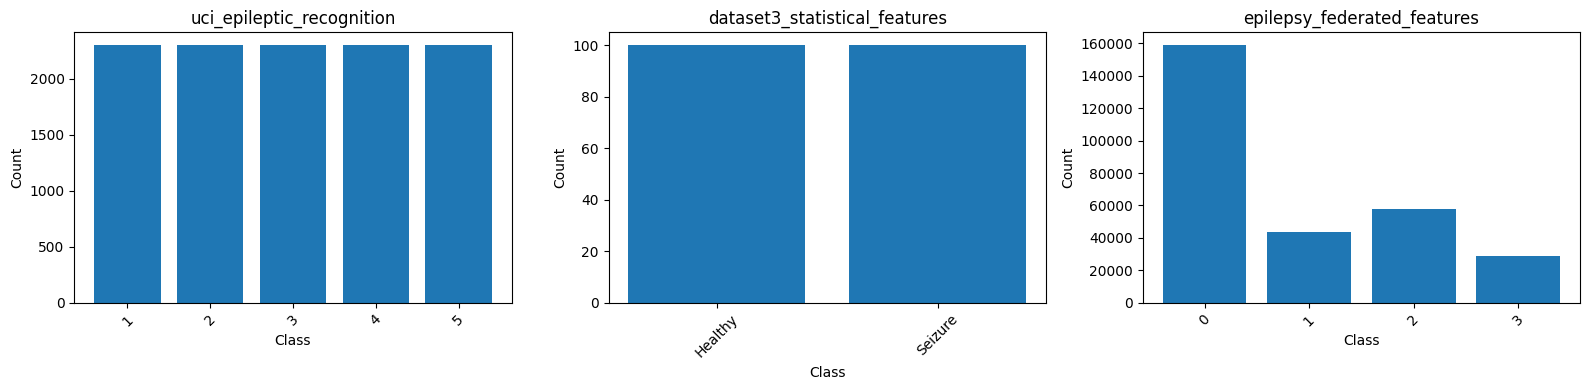

In [6]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed. Install it later with: pip install matplotlib")
    display(class_balance)
else:
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(16, 4))

    for ax, (name, cfg) in zip(axes, DATASETS.items()):
        subset = class_balance[class_balance["dataset"] == name]
        ax.bar(subset["class"].astype(str), subset["count"])
        ax.set_title(name)
        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [7]:
def inspect_dataset_columns(name, n_first=8, n_last=8):
    cfg = DATASETS[name]
    header, rows = read_header_and_sample(cfg["path"], sample_rows=2)
    print(f"Dataset: {name}")
    print(f"File: {cfg['path'].name}")
    print(f"Number of columns: {len(header):,}")
    print(f"Target: {cfg['target']}")
    print(f"First columns: {header[:n_first]}")
    print(f"Last columns: {header[-n_last:]}")
    print(f"Feature type: {cfg['feature_type']}")
    print(f"Label note: {cfg['label_note']}")


for dataset_name in DATASETS:
    inspect_dataset_columns(dataset_name)
    print("-" * 80)

Dataset: uci_epileptic_recognition
File: data.csv
Number of columns: 180
Target: y
First columns: ['', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7']
Last columns: ['X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178', 'y']
Feature type: Raw time-series EEG window features: X1-X178 are ordered signal samples.
Label note: Original labels use 1 for seizure and 2-5 for non-seizure categories. For binary seizure prediction, use y_binary = (y == 1).
--------------------------------------------------------------------------------
Dataset: dataset3_statistical_features
File: dataset3.csv
Number of columns: 12
Target: class
First columns: ['minimum', 'maximum', 'mean', 'standardDev', 'rms', 'zcf', 'variance', 'median']
Last columns: ['rms', 'zcf', 'variance', 'median', 'kurtosis', 'skewness', 'shanonEnt', 'class']
Feature type: Extracted statistical EEG features such as min, max, mean, standard deviation, RMS, zero-crossing count, variance, kurtosis, skewness, and Shannon entropy.
Label note: Use

### Dataset Justification Draft

Use this section in the final report after running the cells above.

- `uci_epileptic_recognition`: useful because it is a compact EEG benchmark with ordered signal-sample features and known seizure vs non-seizure labels. It is suitable for fast baseline experiments and preprocessing-order comparisons.
- `dataset3_statistical_features`: useful because it is a compact extracted-feature dataset with interpretable statistical EEG descriptors, making it suitable for comparing engineered features against raw/time-series-like EEG features.
- `epilepsy_federated_features`: useful because it contains extracted EEG/statistical/spectral/entropy features plus patient-related variables, allowing comparison between raw/time-series-like features and engineered features.

After running the class-balance cells, add the exact row counts and class percentages to the report.

## Step 2: Preprocessing Pipelines

Requirement: design at least two different preprocessing pipelines. We also prepare consistent train/validation/test splits so later model comparisons are fair.

For seizure prediction, the labels are converted to binary targets:

- `data.csv`: seizure = `y == 1`, non-seizure = `y != 1`.
- `dataset3.csv`: seizure = `class == "Seizure"`, non-seizure = `class == "Healthy"`.
- `epilepsy_federated_dataset.csv`: seizure = `Multi_Class_Label != 0`, non-seizure = `Multi_Class_Label == 0`. If the dataset documentation defines class meanings differently, adjust this mapping.

In [8]:
# Step 2 needs scikit-learn. Install it before running this section if the import fails.
try:
    import sklearn
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
    from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
    from sklearn.decomposition import PCA
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "scikit-learn is required from Step 2 onward. Install it with: pip install scikit-learn"
    ) from exc

RANDOM_STATE = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [9]:
def load_dataset_for_modeling(name, max_rows=None):
    """Load one dataset and return numeric features X plus binary target y."""
    cfg = DATASETS[name]
    df = pd.read_csv(cfg["path"], nrows=max_rows)
    target_col = cfg["target"]

    if name == "uci_epileptic_recognition":
        # Drop the unnamed signal-id column and map class 1 to seizure.
        unnamed_cols = [col for col in df.columns if str(col).startswith("Unnamed") or col == ""]
        df = df.drop(columns=unnamed_cols, errors="ignore")
        y = (df[target_col] == 1).astype(int)
        X = df.drop(columns=[target_col])
    elif name == "dataset3_statistical_features":
        y = df[target_col].astype(str).str.lower().eq("seizure").astype(int)
        X = df.drop(columns=[target_col])
    elif name == "epilepsy_federated_features":
        # Treat class 0 as non-seizure/baseline and all other classes as seizure-related.
        y = (df[target_col] != 0).astype(int)
        X = df.drop(columns=[target_col, "Seizure_Type_Label"], errors="ignore")
    else:
        raise ValueError(f"No label mapping defined for {name}")

    X = X.apply(pd.to_numeric, errors="coerce")
    return X, y


prepared_datasets = {}

for name in DATASETS:
    X, y = load_dataset_for_modeling(name)
    prepared_datasets[name] = {"X": X, "y": y}
    print(f"{name}: X={X.shape}, y distribution={y.value_counts().sort_index().to_dict()}")

uci_epileptic_recognition: X=(11500, 178), y distribution={0: 9200, 1: 2300}
dataset3_statistical_features: X=(200, 11), y distribution={0: 100, 1: 100}
epilepsy_federated_features: X=(289010, 50), y distribution={0: 158835, 1: 130175}


In [10]:
def make_train_validation_test_split(X, y, test_size=0.20, validation_size=0.20):
    """Create stratified train/validation/test splits."""
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    relative_validation_size = validation_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval,
        y_trainval,
        test_size=relative_validation_size,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


splits = {}

for name, data in prepared_datasets.items():
    splits[name] = make_train_validation_test_split(data["X"], data["y"])
    X_train, X_val, X_test, y_train, y_val, y_test = splits[name]
    print(f"{name}")
    print(f"  train: {X_train.shape}, {y_train.value_counts().sort_index().to_dict()}")
    print(f"  val:   {X_val.shape}, {y_val.value_counts().sort_index().to_dict()}")
    print(f"  test:  {X_test.shape}, {y_test.value_counts().sort_index().to_dict()}")

uci_epileptic_recognition
  train: (6900, 178), {0: 5520, 1: 1380}
  val:   (2300, 178), {0: 1840, 1: 460}
  test:  (2300, 178), {0: 1840, 1: 460}
dataset3_statistical_features
  train: (120, 11), {0: 60, 1: 60}
  val:   (40, 11), {0: 20, 1: 20}
  test:  (40, 11), {0: 20, 1: 20}
epilepsy_federated_features
  train: (173406, 50), {0: 95301, 1: 78105}
  val:   (57802, 50), {0: 31767, 1: 26035}
  test:  (57802, 50), {0: 31767, 1: 26035}


In [11]:
def build_preprocessing_pipelines(n_features):
    """Return two preprocessing pipelines with different step ordering and goals."""
    k_best = min(30, n_features)
    pca_components = min(20, n_features)

    pipeline_a = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("normalization", StandardScaler()),
            ("noise_low_variance_filter", VarianceThreshold(threshold=0.0)),
            ("feature_selection", SelectKBest(score_func=f_classif, k=k_best)),
        ]
    )

    pipeline_b = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaling", MinMaxScaler()),
            ("pca_feature_extraction", PCA(n_components=pca_components, random_state=RANDOM_STATE)),
            ("post_pca_normalization", StandardScaler()),
        ]
    )

    return {
        "pipeline_a_norm_filter_select": pipeline_a,
        "pipeline_b_scale_pca_norm": pipeline_b,
    }


preprocessing_pipelines = {}

for name, data in prepared_datasets.items():
    preprocessing_pipelines[name] = build_preprocessing_pipelines(data["X"].shape[1])
    print(name)
    for pipeline_name, pipeline in preprocessing_pipelines[name].items():
        print(f"  {pipeline_name}: {[step for step, _ in pipeline.steps]}")

uci_epileptic_recognition
  pipeline_a_norm_filter_select: ['imputer', 'normalization', 'noise_low_variance_filter', 'feature_selection']
  pipeline_b_scale_pca_norm: ['imputer', 'scaling', 'pca_feature_extraction', 'post_pca_normalization']
dataset3_statistical_features
  pipeline_a_norm_filter_select: ['imputer', 'normalization', 'noise_low_variance_filter', 'feature_selection']
  pipeline_b_scale_pca_norm: ['imputer', 'scaling', 'pca_feature_extraction', 'post_pca_normalization']
epilepsy_federated_features
  pipeline_a_norm_filter_select: ['imputer', 'normalization', 'noise_low_variance_filter', 'feature_selection']
  pipeline_b_scale_pca_norm: ['imputer', 'scaling', 'pca_feature_extraction', 'post_pca_normalization']


In [12]:
# Smoke-test the preprocessing pipelines on the training split only.
# This prevents data leakage: validation/test data are transformed later using the fitted training pipeline.
for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    print(dataset_name)
    for pipeline_name, preprocessor in preprocessing_pipelines[dataset_name].items():
        Xt_train = preprocessor.fit_transform(X_train, y_train)
        Xt_val = preprocessor.transform(X_val)
        print(f"  {pipeline_name}: train {Xt_train.shape}, val {Xt_val.shape}")

uci_epileptic_recognition
  pipeline_a_norm_filter_select: train (6900, 30), val (2300, 30)
  pipeline_b_scale_pca_norm: train (6900, 20), val (2300, 20)
dataset3_statistical_features
  pipeline_a_norm_filter_select: train (120, 11), val (40, 11)
  pipeline_b_scale_pca_norm: train (120, 11), val (40, 11)
epilepsy_federated_features
  pipeline_a_norm_filter_select: train (173406, 30), val (57802, 30)
  pipeline_b_scale_pca_norm: train (173406, 20), val (57802, 20)


### Step 2 Report

- Pipeline A follows: median imputation -> normalization -> low-variance feature filtering -> supervised feature selection.
- Pipeline B follows: median imputation -> min-max scaling -> PCA feature extraction -> post-PCA normalization.
- The two pipelines intentionally use different preprocessing order and dimensionality-reduction logic, which allows us to test whether preprocessing order affects seizure prediction performance.
- All preprocessing is fitted on the training split only to avoid data leakage.

## Step 3: Baseline Model - Logistic Regression

Requirement: use Logistic Regression as the core baseline model and report Accuracy, F1-score, and PR-AUC. We train one baseline model for each dataset and each preprocessing pipeline.

In [13]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, average_precision_score, confusion_matrix, classification_report


def build_baseline_model(preprocessor):
    """Attach baseline Logistic Regression to a preprocessing pipeline."""
    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessor)),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def evaluate_binary_classifier(model, X, y, split_name):
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]
    return {
        "split": split_name,
        "accuracy": accuracy_score(y, y_pred),
        "f1_score": f1_score(y, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y, y_score),
    }

print("Building and evaluating baseline models...")
print("complete")

Building and evaluating baseline models...
complete


In [14]:
baseline_results = []
baseline_models = {}

for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    baseline_models[dataset_name] = {}

    for pipeline_name, preprocessor in preprocessing_pipelines[dataset_name].items():
        model = build_baseline_model(preprocessor)
        model.fit(X_train, y_train)
        baseline_models[dataset_name][pipeline_name] = model

        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("validation", X_val, y_val),
            ("test", X_test, y_test),
        ]:
            row = evaluate_binary_classifier(model, X_split, y_split, split_name)
            row.update({"dataset": dataset_name, "pipeline": pipeline_name})
            baseline_results.append(row)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    ["dataset", "pipeline", "split", "accuracy", "f1_score", "pr_auc"]
].sort_values(["dataset", "pipeline", "split"])

baseline_results_df

,dataset,pipeline,split,accuracy,f1_score,pr_auc
8,dataset3_statistical_features,pipeline_a_norm_filter_select,test,1.000000,1.000000,1.000000
6,dataset3_statistical_features,pipeline_a_norm_filter_select,train,0.991667,0.991597,1.000000
7,dataset3_statistical_features,pipeline_a_norm_filter_select,validation,0.950000,0.947368,0.990000
11,dataset3_statistical_features,pipeline_b_scale_pca_norm,test,1.000000,1.000000,1.000000
9,dataset3_statistical_features,pipeline_b_scale_pca_norm,train,1.000000,1.000000,1.000000
10,dataset3_statistical_features,pipeline_b_scale_pca_norm,validation,0.950000,0.947368,0.995455
14,epilepsy_federated_features,pipeline_a_norm_filter_select,test,0.549583,0.000000,0.448995
12,epilepsy_federated_features,pipeline_a_norm_filter_select,train,0.549583,0.000000,0.456510
13,epilepsy_federated_features,pipeline_a_norm_filter_select,validation,0.549583,0.000000,0.450522
17,epilepsy_federated_features,pipeline_b_scale_pca_norm,test,0.549583,0.000000,0.450159


In [15]:
validation_summary = (
    baseline_results_df[baseline_results_df["split"] == "validation"]
    .sort_values(["dataset", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)

validation_summary

,dataset,pipeline,split,accuracy,f1_score,pr_auc
0,dataset3_statistical_features,pipeline_b_scale_pca_norm,validation,0.950000,0.947368,0.995455
1,dataset3_statistical_features,pipeline_a_norm_filter_select,validation,0.950000,0.947368,0.990000
2,epilepsy_federated_features,pipeline_b_scale_pca_norm,validation,0.549583,0.000000,0.451908
3,epilepsy_federated_features,pipeline_a_norm_filter_select,validation,0.549583,0.000000,0.450522
4,uci_epileptic_recognition,pipeline_a_norm_filter_select,validation,0.809565,0.098765,0.452769
5,uci_epileptic_recognition,pipeline_b_scale_pca_norm,validation,0.807391,0.075157,0.438599


In [16]:
test_summary = (
    baseline_results_df[baseline_results_df["split"] == "test"]
    .sort_values(["dataset", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)

test_summary

,dataset,pipeline,split,accuracy,f1_score,pr_auc
0,dataset3_statistical_features,pipeline_a_norm_filter_select,test,1.000000,1.000000,1.000000
1,dataset3_statistical_features,pipeline_b_scale_pca_norm,test,1.000000,1.000000,1.000000
2,epilepsy_federated_features,pipeline_b_scale_pca_norm,test,0.549583,0.000000,0.450159
3,epilepsy_federated_features,pipeline_a_norm_filter_select,test,0.549583,0.000000,0.448995
4,uci_epileptic_recognition,pipeline_a_norm_filter_select,test,0.809565,0.095041,0.459808
5,uci_epileptic_recognition,pipeline_b_scale_pca_norm,test,0.803913,0.038380,0.421060


In [17]:
# Detailed report for the best validation pipeline per dataset.
for dataset_name in DATASETS:
    best_row = validation_summary[validation_summary["dataset"] == dataset_name].iloc[0]
    pipeline_name = best_row["pipeline"]
    model = baseline_models[dataset_name][pipeline_name]
    X_train, X_val, X_test, y_train, y_val, y_test = splits[dataset_name]

    y_pred = model.predict(X_test)
    print("=" * 80)
    print(f"Dataset: {dataset_name}")
    print(f"Best validation pipeline: {pipeline_name}")
    print("Test confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Test classification report:")
    print(classification_report(y_test, y_pred, target_names=["non_seizure", "seizure"], zero_division=0))

Dataset: uci_epileptic_recognition
Best validation pipeline: pipeline_a_norm_filter_select
Test confusion matrix:
[[1839    1]
 [ 437   23]]
Test classification report:
              precision    recall  f1-score   support

 non_seizure       0.81      1.00      0.89      1840
     seizure       0.96      0.05      0.10       460

    accuracy                           0.81      2300
   macro avg       0.88      0.52      0.49      2300
weighted avg       0.84      0.81      0.73      2300

Dataset: dataset3_statistical_features
Best validation pipeline: pipeline_b_scale_pca_norm
Test confusion matrix:
[[20  0]
 [ 0 20]]
Test classification report:
              precision    recall  f1-score   support

 non_seizure       1.00      1.00      1.00        20
     seizure       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Dataset: epileps

### Step 3 Report

- Logistic Regression with L2 regularization is used as the baseline model.
- The same train/validation/test split is reused for both preprocessing pipelines, making the comparison fair.
- PR-AUC is especially important because the binary seizure labels can be imbalanced, especially for the UCI-style dataset and the federated dataset.
- Validation results should be used to compare preprocessing pipelines; test results should be reported as final held-out performance.

## Step 4: Demonstrate Underfitting and Overfitting

Requirement: intentionally create underfitting and overfitting scenarios, then compare training and validation behavior.

We use Logistic Regression settings to create three scenarios:

- Underfitting: limited features plus very strong regularization.
- Reference: reasonable preprocessing plus moderate regularization.
- Overfitting-prone: many/all features plus extremely weak regularization.

In [18]:
def build_fit_diagnostic_pipeline(n_features, scenario):
    """Create intentionally biased pipelines for underfitting/overfitting diagnostics."""
    if scenario == "underfit_strong_regularization_limited_features":
        k = min(5, n_features)
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("feature_limit", SelectKBest(score_func=f_classif, k=k)),
                (
                    "model",
                    LogisticRegression(
                        penalty="l2",
                        C=0.001,
                        solver="liblinear",
                        max_iter=2000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

    if scenario == "reference_moderate_regularization":
        return build_baseline_model(Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        ))

    if scenario == "overfit_weak_regularization_all_features":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        penalty="l2",
                        C=1_000_000,
                        solver="liblinear",
                        max_iter=4000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )

    raise ValueError(f"Unknown scenario: {scenario}")


fit_scenarios = [
    "underfit_strong_regularization_limited_features",
    "reference_moderate_regularization",
    "overfit_weak_regularization_all_features",
]

In [19]:
fit_diagnostic_results = []
fit_diagnostic_models = {}

for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    fit_diagnostic_models[dataset_name] = {}

    for scenario in fit_scenarios:
        model = build_fit_diagnostic_pipeline(X_train.shape[1], scenario)
        model.fit(X_train, y_train)
        fit_diagnostic_models[dataset_name][scenario] = model

        for split_name, X_split, y_split in [
            ("train", X_train, y_train),
            ("validation", X_val, y_val),
        ]:
            row = evaluate_binary_classifier(model, X_split, y_split, split_name)
            row.update({"dataset": dataset_name, "scenario": scenario})
            fit_diagnostic_results.append(row)

fit_diagnostic_df = pd.DataFrame(fit_diagnostic_results)
fit_diagnostic_df = fit_diagnostic_df[
    ["dataset", "scenario", "split", "accuracy", "f1_score", "pr_auc"]
].sort_values(["dataset", "scenario", "split"])

fit_diagnostic_df

,dataset,scenario,split,accuracy,f1_score,pr_auc
10,dataset3_statistical_features,overfit_weak_regularization_all_features,train,1.000000,1.000000,1.000000
11,dataset3_statistical_features,overfit_weak_regularization_all_features,validation,0.950000,0.947368,0.991667
8,dataset3_statistical_features,reference_moderate_regularization,train,0.991667,0.991597,1.000000
9,dataset3_statistical_features,reference_moderate_regularization,validation,0.950000,0.947368,0.990000
6,dataset3_statistical_features,underfit_strong_regularization_limited_features,train,0.875000,0.857143,0.997869
7,dataset3_statistical_features,underfit_strong_regularization_limited_features,validation,0.875000,0.857143,0.995119
16,epilepsy_federated_features,overfit_weak_regularization_all_features,train,0.549583,0.000000,0.456740
17,epilepsy_federated_features,overfit_weak_regularization_all_features,validation,0.549583,0.000000,0.450038
14,epilepsy_federated_features,reference_moderate_regularization,train,0.549583,0.000000,0.456740
15,epilepsy_federated_features,reference_moderate_regularization,validation,0.549583,0.000000,0.450038


In [20]:
fit_gap_rows = []

for (dataset_name, scenario), group in fit_diagnostic_df.groupby(["dataset", "scenario"]):
    train_row = group[group["split"] == "train"].iloc[0]
    val_row = group[group["split"] == "validation"].iloc[0]
    fit_gap_rows.append({
        "dataset": dataset_name,
        "scenario": scenario,
        "train_f1": train_row["f1_score"],
        "validation_f1": val_row["f1_score"],
        "f1_gap_train_minus_val": train_row["f1_score"] - val_row["f1_score"],
        "train_pr_auc": train_row["pr_auc"],
        "validation_pr_auc": val_row["pr_auc"],
        "pr_auc_gap_train_minus_val": train_row["pr_auc"] - val_row["pr_auc"],
    })

fit_gap_df = pd.DataFrame(fit_gap_rows).sort_values(["dataset", "scenario"])
fit_gap_df

,dataset,scenario,train_f1,validation_f1,f1_gap_train_minus_val,train_pr_auc,validation_pr_auc,pr_auc_gap_train_minus_val
0,dataset3_statistical_features,overfit_weak_regularization_all_features,1.000000,0.947368,0.052632,1.000000,0.991667,0.008333
1,dataset3_statistical_features,reference_moderate_regularization,0.991597,0.947368,0.044228,1.000000,0.990000,0.010000
2,dataset3_statistical_features,underfit_strong_regularization_limited_features,0.857143,0.857143,0.000000,0.997869,0.995119,0.002750
3,epilepsy_federated_features,overfit_weak_regularization_all_features,0.000000,0.000000,0.000000,0.456740,0.450038,0.006702
4,epilepsy_federated_features,reference_moderate_regularization,0.000000,0.000000,0.000000,0.456740,0.450038,0.006702
5,epilepsy_federated_features,underfit_strong_regularization_limited_features,0.000000,0.000000,0.000000,0.453992,0.450026,0.003965
6,uci_epileptic_recognition,overfit_weak_regularization_all_features,0.343266,0.235741,0.107524,0.569192,0.415545,0.153647
7,uci_epileptic_recognition,reference_moderate_regularization,0.290303,0.216216,0.074086,0.580165,0.452751,0.127414
8,uci_epileptic_recognition,underfit_strong_regularization_limited_features,0.035587,0.025641,0.009946,0.499944,0.431250,0.068694


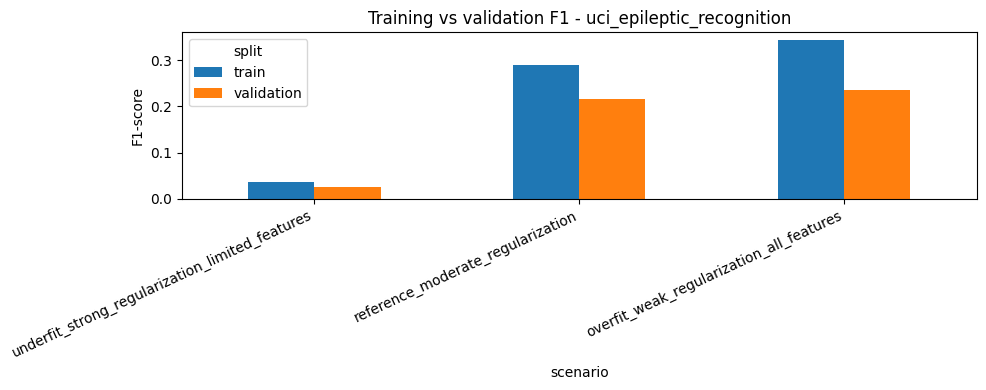

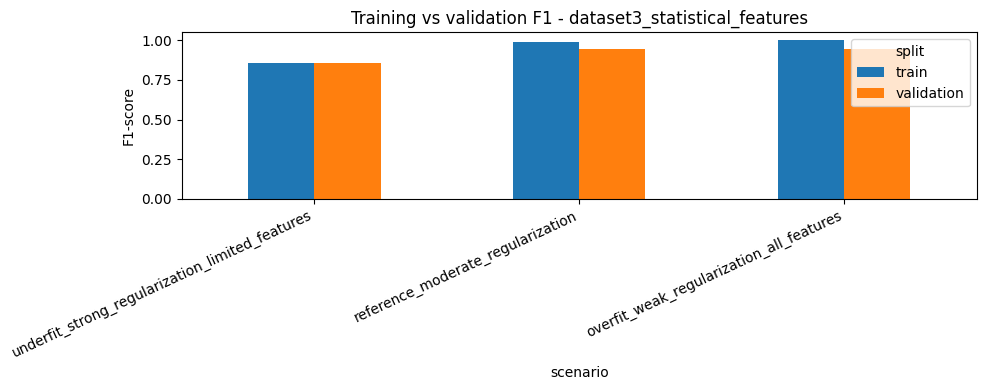

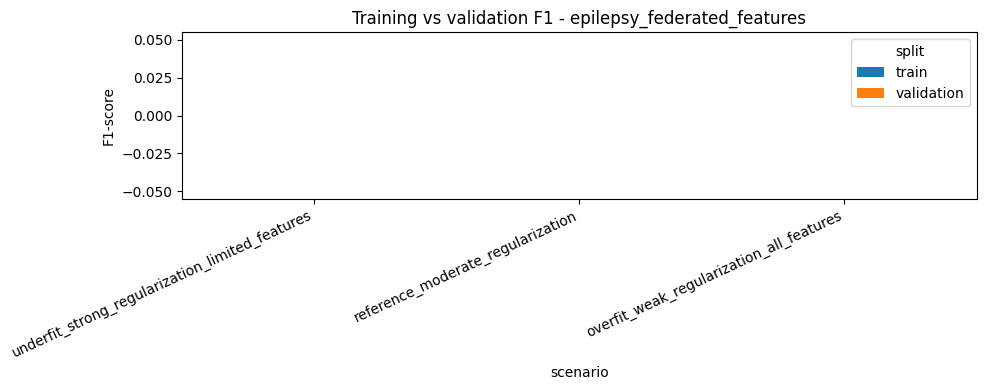

In [21]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed. Showing the fit-gap table instead.")
    display(fit_gap_df)
else:
    for dataset_name in DATASETS:
        subset = fit_diagnostic_df[fit_diagnostic_df["dataset"] == dataset_name]
        pivot = subset.pivot(index="scenario", columns="split", values="f1_score").loc[fit_scenarios]
        pivot.plot(kind="bar", figsize=(10, 4))
        plt.title(f"Training vs validation F1 - {dataset_name}")
        plt.ylabel("F1-score")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

In [22]:
def compute_learning_curve_table(dataset_name, scenario, train_fracs=(0.1, 0.25, 0.5, 0.75, 1.0)):
    X_train, X_val, X_test, y_train, y_val, y_test = splits[dataset_name]
    rows = []

    for frac in train_fracs:
        if frac < 1.0:
            X_sub, _, y_sub, _ = train_test_split(
                X_train,
                y_train,
                train_size=frac,
                random_state=RANDOM_STATE,
                stratify=y_train,
            )
        else:
            X_sub, y_sub = X_train, y_train

        model = build_fit_diagnostic_pipeline(X_train.shape[1], scenario)
        model.fit(X_sub, y_sub)
        train_metrics = evaluate_binary_classifier(model, X_sub, y_sub, "train_subset")
        val_metrics = evaluate_binary_classifier(model, X_val, y_val, "validation")

        rows.append({
            "dataset": dataset_name,
            "scenario": scenario,
            "train_fraction": frac,
            "train_rows": len(X_sub),
            "train_f1": train_metrics["f1_score"],
            "validation_f1": val_metrics["f1_score"],
            "train_pr_auc": train_metrics["pr_auc"],
            "validation_pr_auc": val_metrics["pr_auc"],
        })

    return pd.DataFrame(rows)


learning_curve_tables = []

for dataset_name in DATASETS:
    for scenario in fit_scenarios:
        learning_curve_tables.append(compute_learning_curve_table(dataset_name, scenario))

learning_curve_df = pd.concat(learning_curve_tables, ignore_index=True)
learning_curve_df

,dataset,scenario,train_fraction,train_rows,train_f1,validation_f1,train_pr_auc,validation_pr_auc
0,uci_epileptic_recognition,underfit_strong_regularization_limited_features,0.10,690,0.438202,0.381944,0.566280,0.473846
1,uci_epileptic_recognition,underfit_strong_regularization_limited_features,0.25,1725,0.184211,0.177866,0.497184,0.474788
2,uci_epileptic_recognition,underfit_strong_regularization_limited_features,0.50,3450,0.075209,0.070981,0.503726,0.424205
3,uci_epileptic_recognition,underfit_strong_regularization_limited_features,0.75,5175,0.041627,0.042373,0.504417,0.432730
4,uci_epileptic_recognition,underfit_strong_regularization_limited_features,1.00,6900,0.035587,0.025641,0.499944,0.431250
5,uci_epileptic_recognition,reference_moderate_regularization,0.10,690,0.721461,0.412541,0.840323,0.456404
6,uci_epileptic_recognition,reference_moderate_regularization,0.25,1725,0.525424,0.372174,0.717926,0.465507
7,uci_epileptic_recognition,reference_moderate_regularization,0.50,3450,0.385514,0.237548,0.607703,0.462366
8,uci_epileptic_recognition,reference_moderate_regularization,0.75,5175,0.319546,0.213178,0.600854,0.454663
9,uci_epileptic_recognition,reference_moderate_regularization,1.00,6900,0.290303,0.216216,0.580165,0.452751


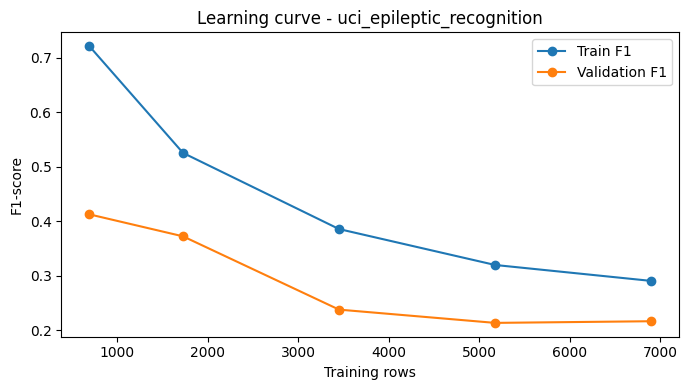

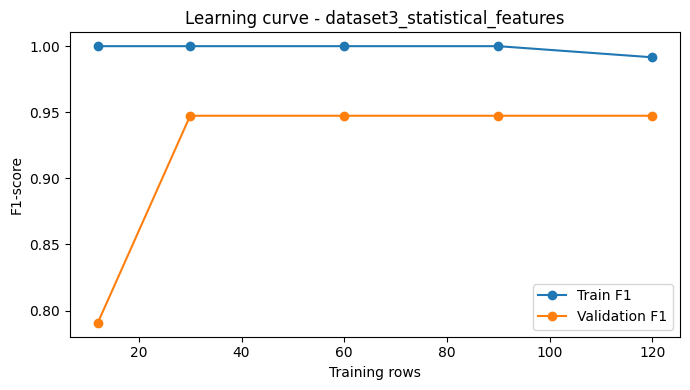

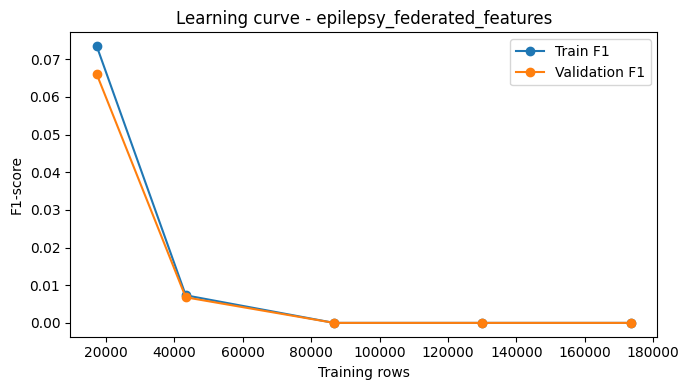

In [23]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed. Showing the learning-curve table instead.")
    display(learning_curve_df)
else:
    for dataset_name in DATASETS:
        subset = learning_curve_df[
            (learning_curve_df["dataset"] == dataset_name)
            & (learning_curve_df["scenario"] == "reference_moderate_regularization")
        ]
        plt.figure(figsize=(7, 4))
        plt.plot(subset["train_rows"], subset["train_f1"], marker="o", label="Train F1")
        plt.plot(subset["train_rows"], subset["validation_f1"], marker="o", label="Validation F1")
        plt.title(f"Learning curve - {dataset_name}")
        plt.xlabel("Training rows")
        plt.ylabel("F1-score")
        plt.legend()
        plt.tight_layout()
        plt.show()

### Step 4 Report

- Underfitting is indicated when both training and validation metrics are low.
- Overfitting is indicated when training metrics are much higher than validation metrics.
- The `fit_gap_df` table measures this gap directly using F1-score and PR-AUC.
- The learning-curve table/plots show whether adding more training data improves validation performance.

## Step 5: Regularization Study

Requirement: compare L1, L2, and Elastic Net regularization, analyze sparsity, and compare stability across datasets.

We use the same preprocessing pipeline for all three regularization types so the comparison isolates the regularization effect. Pipeline A is used because it keeps selected original features, making coefficient sparsity easier to interpret.

In [24]:
def build_regularized_logistic_model(preprocessor, regularization):
    """Build Logistic Regression with the requested regularization type."""
    common_kwargs = {
        "max_iter": 4000,
        "random_state": RANDOM_STATE,
        "class_weight": None,
    }

    if regularization == "l1_lasso":
        model = LogisticRegression(
            penalty="l1",
            solver="saga",
            C=1.0,
            **common_kwargs,
        )
    elif regularization == "l2_ridge":
        model = LogisticRegression(
            penalty="l2",
            solver="saga",
            C=1.0,
            **common_kwargs,
        )
    elif regularization == "elastic_net":
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=1.0,
            l1_ratio=0.5,
            **common_kwargs,
        )
    else:
        raise ValueError(f"Unknown regularization: {regularization}")

    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessor)),
            ("model", model),
        ]
    )


def coefficient_sparsity(fitted_pipeline, zero_tolerance=1e-8):
    coefs = fitted_pipeline.named_steps["model"].coef_.ravel()
    zero_count = int(np.sum(np.abs(coefs) <= zero_tolerance))
    total_count = int(coefs.size)
    return {
        "n_coefficients": total_count,
        "zero_coefficients": zero_count,
        "nonzero_coefficients": total_count - zero_count,
        "sparsity_pct": round((zero_count / total_count) * 100, 2) if total_count else 0.0,
    }


regularization_types = ["l1_lasso", "l2_ridge", "elastic_net"]

In [25]:
regularization_results = []
regularization_models = {}

for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    regularization_models[dataset_name] = {}
    base_preprocessor = preprocessing_pipelines[dataset_name]["pipeline_a_norm_filter_select"]

    for regularization in regularization_types:
        model = build_regularized_logistic_model(base_preprocessor, regularization)
        model.fit(X_train, y_train)
        regularization_models[dataset_name][regularization] = model
        sparsity = coefficient_sparsity(model)

        for split_name, X_split, y_split in [
            ("validation", X_val, y_val),
            ("test", X_test, y_test),
        ]:
            row = evaluate_binary_classifier(model, X_split, y_split, split_name)
            row.update({
                "dataset": dataset_name,
                "regularization": regularization,
                **sparsity,
            })
            regularization_results.append(row)

regularization_results_df = pd.DataFrame(regularization_results)
regularization_results_df = regularization_results_df[
    [
        "dataset",
        "regularization",
        "split",
        "accuracy",
        "f1_score",
        "pr_auc",
        "n_coefficients",
        "zero_coefficients",
        "nonzero_coefficients",
        "sparsity_pct",
    ]
].sort_values(["dataset", "regularization", "split"])

regularization_results_df

,dataset,regularization,split,accuracy,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct
11,dataset3_statistical_features,elastic_net,test,1.000000,1.000000,1.000000,11,2,9,18.18
10,dataset3_statistical_features,elastic_net,validation,0.950000,0.947368,0.991667,11,2,9,18.18
7,dataset3_statistical_features,l1_lasso,test,1.000000,1.000000,1.000000,11,8,3,72.73
6,dataset3_statistical_features,l1_lasso,validation,0.950000,0.947368,0.995455,11,8,3,72.73
9,dataset3_statistical_features,l2_ridge,test,1.000000,1.000000,1.000000,11,0,11,0.00
8,dataset3_statistical_features,l2_ridge,validation,0.950000,0.947368,0.991667,11,0,11,0.00
17,epilepsy_federated_features,elastic_net,test,0.549583,0.000000,0.448997,30,0,30,0.00
16,epilepsy_federated_features,elastic_net,validation,0.549583,0.000000,0.450521,30,0,30,0.00
13,epilepsy_federated_features,l1_lasso,test,0.549583,0.000000,0.448998,30,0,30,0.00
12,epilepsy_federated_features,l1_lasso,validation,0.549583,0.000000,0.450518,30,0,30,0.00


In [26]:
regularization_validation_summary = (
    regularization_results_df[regularization_results_df["split"] == "validation"]
    .sort_values(["dataset", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)

regularization_validation_summary

,dataset,regularization,split,accuracy,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct
0,dataset3_statistical_features,l1_lasso,validation,0.950000,0.947368,0.995455,11,8,3,72.73
1,dataset3_statistical_features,elastic_net,validation,0.950000,0.947368,0.991667,11,2,9,18.18
2,dataset3_statistical_features,l2_ridge,validation,0.950000,0.947368,0.991667,11,0,11,0.00
3,epilepsy_federated_features,l2_ridge,validation,0.549583,0.000000,0.450522,30,0,30,0.00
4,epilepsy_federated_features,elastic_net,validation,0.549583,0.000000,0.450521,30,0,30,0.00
5,epilepsy_federated_features,l1_lasso,validation,0.549583,0.000000,0.450518,30,0,30,0.00
6,uci_epileptic_recognition,l2_ridge,validation,0.809565,0.098765,0.453040,30,0,30,0.00
7,uci_epileptic_recognition,elastic_net,validation,0.809565,0.098765,0.451719,30,1,29,3.33
8,uci_epileptic_recognition,l1_lasso,validation,0.808696,0.090909,0.450788,30,4,26,13.33


In [27]:
regularization_test_summary = (
    regularization_results_df[regularization_results_df["split"] == "test"]
    .sort_values(["dataset", "pr_auc"], ascending=[True, False])
    .reset_index(drop=True)
)

regularization_test_summary

,dataset,regularization,split,accuracy,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct
0,dataset3_statistical_features,elastic_net,test,1.000000,1.000000,1.000000,11,2,9,18.18
1,dataset3_statistical_features,l1_lasso,test,1.000000,1.000000,1.000000,11,8,3,72.73
2,dataset3_statistical_features,l2_ridge,test,1.000000,1.000000,1.000000,11,0,11,0.00
3,epilepsy_federated_features,l1_lasso,test,0.549583,0.000000,0.448998,30,0,30,0.00
4,epilepsy_federated_features,elastic_net,test,0.549583,0.000000,0.448997,30,0,30,0.00
5,epilepsy_federated_features,l2_ridge,test,0.549583,0.000000,0.448995,30,0,30,0.00
6,uci_epileptic_recognition,l2_ridge,test,0.809565,0.095041,0.459849,30,0,30,0.00
7,uci_epileptic_recognition,l1_lasso,test,0.808261,0.083160,0.459466,30,4,26,13.33
8,uci_epileptic_recognition,elastic_net,test,0.809130,0.091097,0.459243,30,1,29,3.33


In [28]:
stability_rows = []

for regularization in regularization_types:
    subset = regularization_validation_summary[
        regularization_validation_summary["regularization"] == regularization
    ]
    stability_rows.append({
        "regularization": regularization,
        "mean_validation_pr_auc": subset["pr_auc"].mean(),
        "std_validation_pr_auc": subset["pr_auc"].std(ddof=0),
        "mean_validation_f1": subset["f1_score"].mean(),
        "std_validation_f1": subset["f1_score"].std(ddof=0),
        "mean_sparsity_pct": subset["sparsity_pct"].mean(),
    })

regularization_stability_df = pd.DataFrame(stability_rows).sort_values(
    "mean_validation_pr_auc", ascending=False
)

regularization_stability_df

,regularization,mean_validation_pr_auc,std_validation_pr_auc,mean_validation_f1,std_validation_f1,mean_sparsity_pct
0,l1_lasso,0.632254,0.256822,0.346093,0.426783,28.686667
1,l2_ridge,0.631743,0.254507,0.348711,0.425230,0.000000
2,elastic_net,0.631302,0.254816,0.348711,0.425230,7.170000


In [29]:
best_regularization_by_dataset = (
    regularization_validation_summary
    .sort_values(["dataset", "pr_auc"], ascending=[True, False])
    .groupby("dataset")
    .head(1)
    .reset_index(drop=True)
)

best_regularization_by_dataset

,dataset,regularization,split,accuracy,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct
0,dataset3_statistical_features,l1_lasso,validation,0.950000,0.947368,0.995455,11,8,3,72.73
1,epilepsy_federated_features,l2_ridge,validation,0.549583,0.000000,0.450522,30,0,30,0.00
2,uci_epileptic_recognition,l2_ridge,validation,0.809565,0.098765,0.453040,30,0,30,0.00


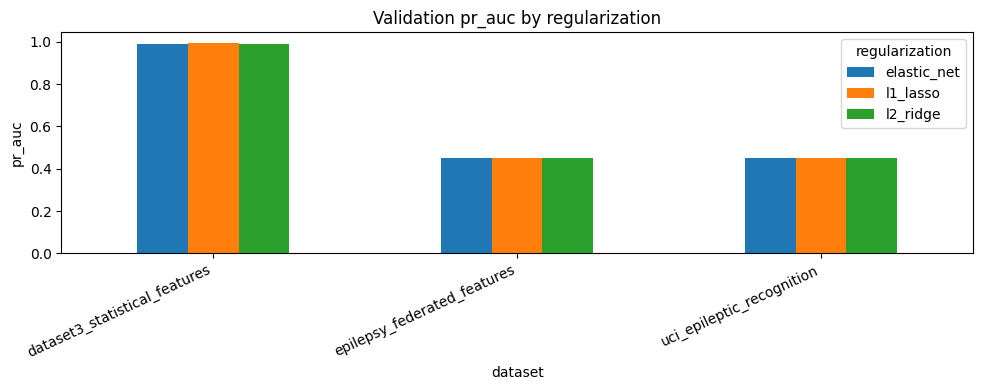

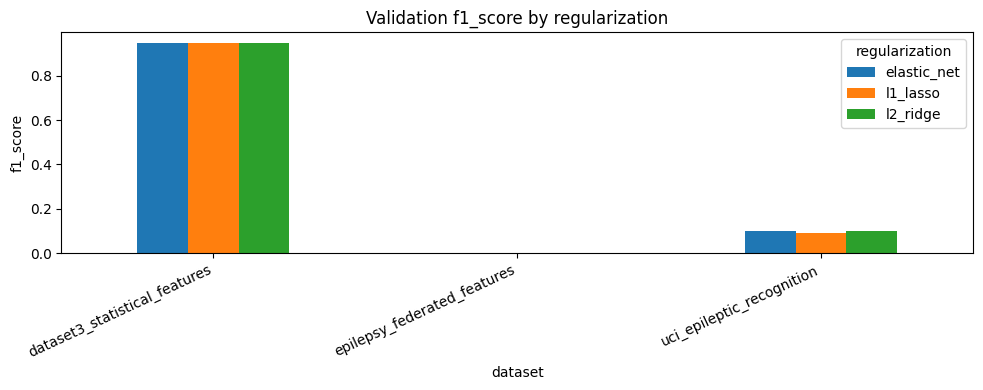

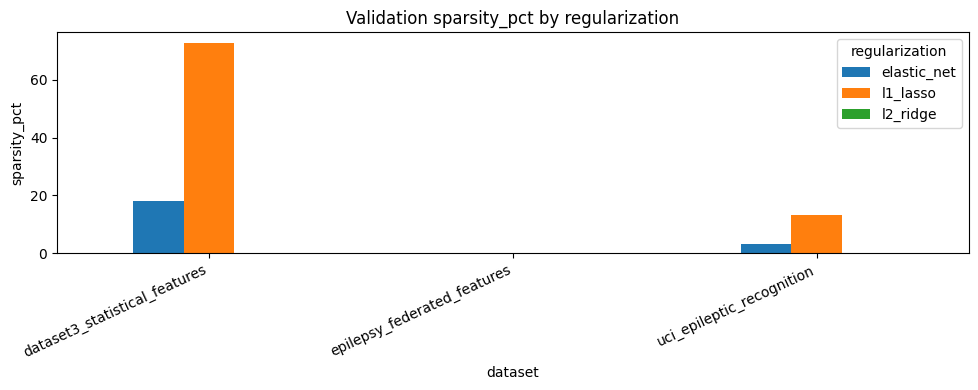

In [30]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed. Showing regularization tables instead.")
    display(regularization_validation_summary)
    display(regularization_stability_df)
else:
    for metric in ["pr_auc", "f1_score", "sparsity_pct"]:
        pivot = regularization_validation_summary.pivot(
            index="dataset", columns="regularization", values=metric
        )
        pivot.plot(kind="bar", figsize=(10, 4))
        plt.title(f"Validation {metric} by regularization")
        plt.ylabel(metric)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

### Step 5 Report

- L1 should usually create sparse coefficients, so it acts like embedded feature selection.
- L2 usually keeps all coefficients nonzero and controls coefficient magnitude rather than selecting features.
- Elastic Net combines L1 and L2, so it may create some sparsity while remaining more stable than pure L1.
- Use `regularization_stability_df` to discuss which regularization generalizes most consistently across datasets.
- Use `best_regularization_by_dataset` to answer whether Elastic Net consistently outperforms L1/L2.

## Step 6: Handling Class Imbalance

Requirement: apply at least two class-imbalance techniques and evaluate the precision vs recall tradeoff.

This section compares:

- No imbalance handling.
- Class weighting using `class_weight="balanced"`.
- Random undersampling of the majority class.

SMOTE is also acceptable for the report, but it requires `imbalanced-learn`. This notebook uses class weighting and undersampling so it remains runnable with only scikit-learn.

In [31]:
from sklearn.metrics import precision_score, recall_score


def random_undersample_binary(X, y, random_state=RANDOM_STATE):
    """Balance binary classes by undersampling the majority class."""
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y)
    classes, counts = np.unique(y_array, return_counts=True)

    if len(classes) != 2:
        raise ValueError("This undersampling helper expects binary labels.")

    minority_count = counts.min()
    selected_indices = []

    for cls in classes:
        cls_indices = np.flatnonzero(y_array == cls)
        sampled = rng.choice(cls_indices, size=minority_count, replace=False)
        selected_indices.extend(sampled.tolist())

    selected_indices = rng.permutation(selected_indices)
    return X.iloc[selected_indices].copy(), y.iloc[selected_indices].copy()


def build_imbalance_model(preprocessor, technique):
    class_weight = "balanced" if technique == "class_weight_balanced" else None
    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessor)),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    class_weight=class_weight,
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def evaluate_precision_recall(model, X, y, split_name):
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]
    return {
        "split": split_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1_score": f1_score(y, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y, y_score),
    }


imbalance_techniques = [
    "none",
    "class_weight_balanced",
    "random_undersampling",
]

In [32]:
imbalance_results = []
imbalance_models = {}

for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    imbalance_models[dataset_name] = {}
    base_preprocessor = preprocessing_pipelines[dataset_name]["pipeline_a_norm_filter_select"]

    for technique in imbalance_techniques:
        if technique == "random_undersampling":
            X_fit, y_fit = random_undersample_binary(X_train, y_train)
        else:
            X_fit, y_fit = X_train, y_train

        model = build_imbalance_model(base_preprocessor, technique)
        model.fit(X_fit, y_fit)
        imbalance_models[dataset_name][technique] = model

        for split_name, X_split, y_split in [
            ("validation", X_val, y_val),
            ("test", X_test, y_test),
        ]:
            row = evaluate_precision_recall(model, X_split, y_split, split_name)
            row.update({
                "dataset": dataset_name,
                "technique": technique,
                "fit_rows": len(X_fit),
                "fit_class_counts": dict(pd.Series(y_fit).value_counts().sort_index()),
            })
            imbalance_results.append(row)

imbalance_results_df = pd.DataFrame(imbalance_results)
imbalance_results_df = imbalance_results_df[
    [
        "dataset",
        "technique",
        "split",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "pr_auc",
        "fit_rows",
        "fit_class_counts",
    ]
].sort_values(["dataset", "technique", "split"])

imbalance_results_df

,dataset,technique,split,accuracy,precision,recall,f1_score,pr_auc,fit_rows,fit_class_counts
9,dataset3_statistical_features,class_weight_balanced,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
8,dataset3_statistical_features,class_weight_balanced,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
7,dataset3_statistical_features,none,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
6,dataset3_statistical_features,none,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
11,dataset3_statistical_features,random_undersampling,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
10,dataset3_statistical_features,random_undersampling,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
15,epilepsy_federated_features,class_weight_balanced,test,0.502422,0.452363,0.497138,0.473695,0.448999,173406,"{0: 95301, 1: 78105}"
14,epilepsy_federated_features,class_weight_balanced,validation,0.500744,0.450841,0.497215,0.472894,0.450523,173406,"{0: 95301, 1: 78105}"
13,epilepsy_federated_features,none,test,0.549583,0.000000,0.000000,0.000000,0.448995,173406,"{0: 95301, 1: 78105}"
12,epilepsy_federated_features,none,validation,0.549583,0.000000,0.000000,0.000000,0.450522,173406,"{0: 95301, 1: 78105}"


In [33]:
imbalance_validation_summary = (
    imbalance_results_df[imbalance_results_df["split"] == "validation"]
    .sort_values(["dataset", "f1_score"], ascending=[True, False])
    .reset_index(drop=True)
)

imbalance_validation_summary

,dataset,technique,split,accuracy,precision,recall,f1_score,pr_auc,fit_rows,fit_class_counts
0,dataset3_statistical_features,class_weight_balanced,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
1,dataset3_statistical_features,none,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
2,dataset3_statistical_features,random_undersampling,validation,0.950000,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
3,epilepsy_federated_features,random_undersampling,validation,0.500571,0.451035,0.501171,0.474783,0.449798,156210,"{0: 78105, 1: 78105}"
4,epilepsy_federated_features,class_weight_balanced,validation,0.500744,0.450841,0.497215,0.472894,0.450523,173406,"{0: 95301, 1: 78105}"
5,epilepsy_federated_features,none,validation,0.549583,0.000000,0.000000,0.000000,0.450522,173406,"{0: 95301, 1: 78105}"
6,uci_epileptic_recognition,class_weight_balanced,validation,0.679130,0.299133,0.450000,0.359375,0.445483,6900,"{0: 5520, 1: 1380}"
7,uci_epileptic_recognition,random_undersampling,validation,0.660000,0.273239,0.421739,0.331624,0.428265,2760,"{0: 1380, 1: 1380}"
8,uci_epileptic_recognition,none,validation,0.809565,0.923077,0.052174,0.098765,0.452769,6900,"{0: 5520, 1: 1380}"


In [34]:
imbalance_test_summary = (
    imbalance_results_df[imbalance_results_df["split"] == "test"]
    .sort_values(["dataset", "f1_score"], ascending=[True, False])
    .reset_index(drop=True)
)

imbalance_test_summary

,dataset,technique,split,accuracy,precision,recall,f1_score,pr_auc,fit_rows,fit_class_counts
0,dataset3_statistical_features,class_weight_balanced,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
1,dataset3_statistical_features,none,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
2,dataset3_statistical_features,random_undersampling,test,1.000000,1.000000,1.000000,1.000000,1.000000,120,"{0: 60, 1: 60}"
3,epilepsy_federated_features,random_undersampling,test,0.500830,0.451175,0.500096,0.474377,0.448785,156210,"{0: 78105, 1: 78105}"
4,epilepsy_federated_features,class_weight_balanced,test,0.502422,0.452363,0.497138,0.473695,0.448999,173406,"{0: 95301, 1: 78105}"
5,epilepsy_federated_features,none,test,0.549583,0.000000,0.000000,0.000000,0.448995,173406,"{0: 95301, 1: 78105}"
6,uci_epileptic_recognition,class_weight_balanced,test,0.679130,0.305866,0.476087,0.372449,0.451946,6900,"{0: 5520, 1: 1380}"
7,uci_epileptic_recognition,random_undersampling,test,0.671739,0.293128,0.454348,0.356351,0.451743,2760,"{0: 1380, 1: 1380}"
8,uci_epileptic_recognition,none,test,0.809565,0.958333,0.050000,0.095041,0.459808,6900,"{0: 5520, 1: 1380}"


In [35]:
tradeoff_rows = []

for dataset_name in DATASETS:
    subset = imbalance_validation_summary[imbalance_validation_summary["dataset"] == dataset_name]
    baseline = subset[subset["technique"] == "none"].iloc[0]

    for _, row in subset.iterrows():
        tradeoff_rows.append({
            "dataset": dataset_name,
            "technique": row["technique"],
            "precision_change_vs_none": row["precision"] - baseline["precision"],
            "recall_change_vs_none": row["recall"] - baseline["recall"],
            "f1_change_vs_none": row["f1_score"] - baseline["f1_score"],
            "pr_auc_change_vs_none": row["pr_auc"] - baseline["pr_auc"],
        })

precision_recall_tradeoff_df = pd.DataFrame(tradeoff_rows).sort_values(["dataset", "technique"])
precision_recall_tradeoff_df

,dataset,technique,precision_change_vs_none,recall_change_vs_none,f1_change_vs_none,pr_auc_change_vs_none
3,dataset3_statistical_features,class_weight_balanced,0.000000,0.000000,0.000000,0.000000
4,dataset3_statistical_features,none,0.000000,0.000000,0.000000,0.000000
5,dataset3_statistical_features,random_undersampling,0.000000,0.000000,0.000000,0.000000
7,epilepsy_federated_features,class_weight_balanced,0.450841,0.497215,0.472894,0.000001
8,epilepsy_federated_features,none,0.000000,0.000000,0.000000,0.000000
6,epilepsy_federated_features,random_undersampling,0.451035,0.501171,0.474783,-0.000724
0,uci_epileptic_recognition,class_weight_balanced,-0.623944,0.397826,0.260610,-0.007286
2,uci_epileptic_recognition,none,0.000000,0.000000,0.000000,0.000000
1,uci_epileptic_recognition,random_undersampling,-0.649837,0.369565,0.232858,-0.024505


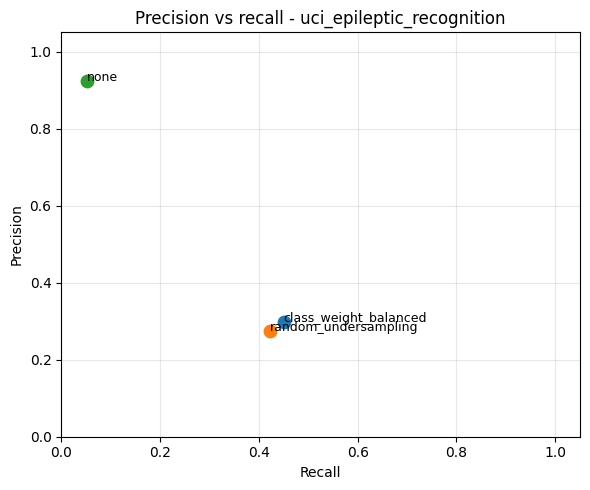

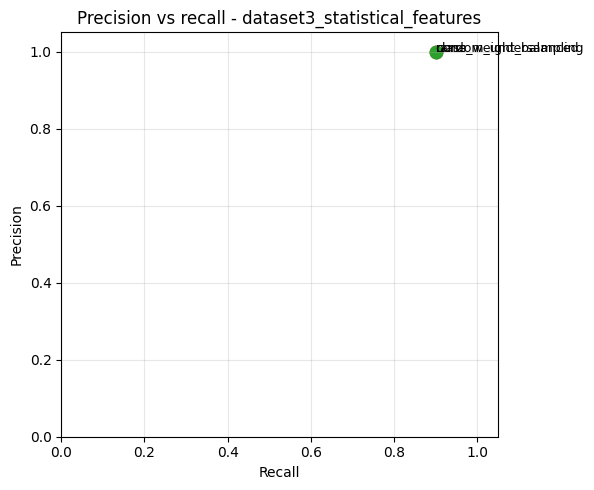

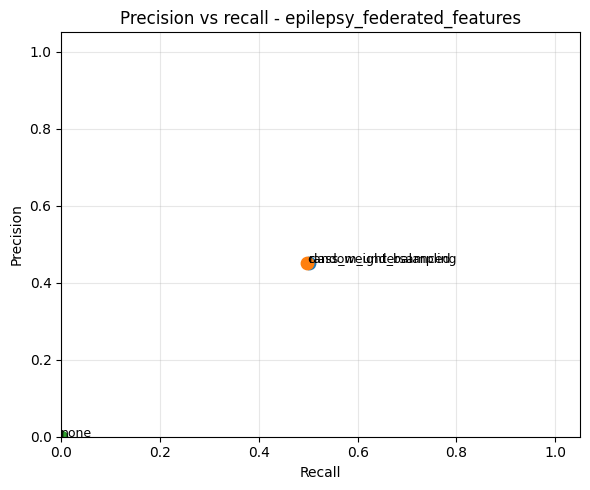

In [36]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print("matplotlib is not installed. Showing precision-recall tradeoff table instead.")
    display(precision_recall_tradeoff_df)
else:
    for dataset_name in DATASETS:
        subset = imbalance_validation_summary[imbalance_validation_summary["dataset"] == dataset_name]
        plt.figure(figsize=(6, 5))
        for _, row in subset.iterrows():
            plt.scatter(row["recall"], row["precision"], s=80)
            plt.text(row["recall"], row["precision"], row["technique"], fontsize=9)
        plt.title(f"Precision vs recall - {dataset_name}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.xlim(0, 1.05)
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Step 6 Report

- Class weighting keeps all training samples but changes the penalty so minority-class mistakes matter more.
- Random undersampling balances the training set by dropping majority-class samples, which may improve recall but can discard useful information.
- Use `precision_recall_tradeoff_df` to explain whether imbalance handling improves recall at the cost of precision.
- PR-AUC remains important because it summarizes performance across different decision thresholds.

## Step 7: Final Comparative Analysis

Requirement: answer the main research questions using the results from previous sections.

Questions to answer:

- Does preprocessing order affect results?
- Which regularization generalizes best across datasets?
- Does Elastic Net consistently outperform L1/L2?
- How does imbalance handling interact with regularization?

In [37]:
# 1. Does preprocessing order affect results?
preprocessing_comparison_df = (
    baseline_results_df[baseline_results_df["split"] == "validation"]
    .pivot(index="dataset", columns="pipeline", values=["accuracy", "f1_score", "pr_auc"])
)

preprocessing_comparison_df

accuracy  \
pipeline                      pipeline_a_norm_filter_select   
dataset                                                       
dataset3_statistical_features                      0.950000   
epilepsy_federated_features                        0.549583   
uci_epileptic_recognition                          0.809565   

                                                         \
pipeline                      pipeline_b_scale_pca_norm   
dataset                                                   
dataset3_statistical_features                  0.950000   
epilepsy_federated_features                    0.549583   
uci_epileptic_recognition                      0.807391   

                                                   f1_score  \
pipeline                      pipeline_a_norm_filter_select   
dataset                                                       
dataset3_statistical_features                      0.947368   
epilepsy_federated_features                        0.000000   
uci_epileptic_recognition                          0.098765   

                                                         \
pipeline                      pipeline_b_scale_pca_norm   
dataset                                                   
dataset3_statistical_features                  0.947368   
epilepsy_federated_features                    0.000000   
uci_epileptic_recognition                      0.075157   

                                                     pr_auc  \
pipeline                      pipeline_a_norm_filter_select   
dataset                                                       
dataset3_statistical_features                      0.990000   
epilepsy_federated_features                        0.450522   
uci_epileptic_recognition                          0.452769   

                                                         
pipeline                      pipeline_b_scale_pca_norm  
dataset                                                  
dataset3_statistical_features                  0.995455  
epilepsy_federated_features                    0.451908  
uci_epileptic_recognition                      0.438599

In [38]:
preprocessing_effect_rows = []

for dataset_name in DATASETS:
    subset = baseline_results_df[
        (baseline_results_df["dataset"] == dataset_name)
        & (baseline_results_df["split"] == "validation")
    ]
    best = subset.sort_values("pr_auc", ascending=False).iloc[0]
    worst = subset.sort_values("pr_auc", ascending=True).iloc[0]
    preprocessing_effect_rows.append({
        "dataset": dataset_name,
        "best_pipeline": best["pipeline"],
        "best_validation_pr_auc": best["pr_auc"],
        "worst_pipeline": worst["pipeline"],
        "worst_validation_pr_auc": worst["pr_auc"],
        "pr_auc_difference": best["pr_auc"] - worst["pr_auc"],
        "preprocessing_order_mattered": (best["pr_auc"] - worst["pr_auc"]) > 0.01,
    })

preprocessing_effect_df = pd.DataFrame(preprocessing_effect_rows)
preprocessing_effect_df

,dataset,best_pipeline,best_validation_pr_auc,worst_pipeline,worst_validation_pr_auc,pr_auc_difference,preprocessing_order_mattered
0,uci_epileptic_recognition,pipeline_a_norm_filter_select,0.452769,pipeline_b_scale_pca_norm,0.438599,0.014171,True
1,dataset3_statistical_features,pipeline_b_scale_pca_norm,0.995455,pipeline_a_norm_filter_select,0.990000,0.005455,False
2,epilepsy_federated_features,pipeline_b_scale_pca_norm,0.451908,pipeline_a_norm_filter_select,0.450522,0.001386,False


In [39]:
# 2. Which regularization generalizes best across datasets?
regularization_rank_df = regularization_validation_summary.copy()
regularization_rank_df["rank_within_dataset"] = regularization_rank_df.groupby("dataset")["pr_auc"].rank(
    method="dense", ascending=False
)

regularization_rank_df.sort_values(["dataset", "rank_within_dataset"])

,dataset,regularization,split,accuracy,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct,rank_within_dataset
0,dataset3_statistical_features,l1_lasso,validation,0.950000,0.947368,0.995455,11,8,3,72.73,1.0
1,dataset3_statistical_features,elastic_net,validation,0.950000,0.947368,0.991667,11,2,9,18.18,2.0
2,dataset3_statistical_features,l2_ridge,validation,0.950000,0.947368,0.991667,11,0,11,0.00,2.0
3,epilepsy_federated_features,l2_ridge,validation,0.549583,0.000000,0.450522,30,0,30,0.00,1.0
4,epilepsy_federated_features,elastic_net,validation,0.549583,0.000000,0.450521,30,0,30,0.00,2.0
5,epilepsy_federated_features,l1_lasso,validation,0.549583,0.000000,0.450518,30,0,30,0.00,3.0
6,uci_epileptic_recognition,l2_ridge,validation,0.809565,0.098765,0.453040,30,0,30,0.00,1.0
7,uci_epileptic_recognition,elastic_net,validation,0.809565,0.098765,0.451719,30,1,29,3.33,2.0
8,uci_epileptic_recognition,l1_lasso,validation,0.808696,0.090909,0.450788,30,4,26,13.33,3.0


In [40]:
regularization_generalization_df = (
    regularization_rank_df.groupby("regularization")
    .agg(
        mean_validation_pr_auc=("pr_auc", "mean"),
        std_validation_pr_auc=("pr_auc", "std"),
        mean_validation_f1=("f1_score", "mean"),
        mean_rank=("rank_within_dataset", "mean"),
        datasets_best=("rank_within_dataset", lambda s: int((s == 1).sum())),
        mean_sparsity_pct=("sparsity_pct", "mean"),
    )
    .reset_index()
    .sort_values(["mean_rank", "mean_validation_pr_auc"], ascending=[True, False])
)

regularization_generalization_df

,regularization,mean_validation_pr_auc,std_validation_pr_auc,mean_validation_f1,mean_rank,datasets_best,mean_sparsity_pct
2,l2_ridge,0.631743,0.311706,0.348711,1.333333,2,0.000000
0,elastic_net,0.631302,0.312085,0.348711,2.000000,0,7.170000
1,l1_lasso,0.632254,0.314541,0.346093,2.333333,1,28.686667


In [41]:
# 3. Does Elastic Net consistently outperform L1/L2?
elastic_net_rows = []

for dataset_name in DATASETS:
    subset = regularization_validation_summary[regularization_validation_summary["dataset"] == dataset_name]
    elastic = subset[subset["regularization"] == "elastic_net"].iloc[0]
    best_other = subset[subset["regularization"] != "elastic_net"].sort_values("pr_auc", ascending=False).iloc[0]
    elastic_net_rows.append({
        "dataset": dataset_name,
        "elastic_net_pr_auc": elastic["pr_auc"],
        "best_non_elastic_regularization": best_other["regularization"],
        "best_non_elastic_pr_auc": best_other["pr_auc"],
        "elastic_net_margin": elastic["pr_auc"] - best_other["pr_auc"],
        "elastic_net_outperformed_l1_l2": elastic["pr_auc"] > best_other["pr_auc"],
    })

elastic_net_comparison_df = pd.DataFrame(elastic_net_rows)
elastic_net_comparison_df

,dataset,elastic_net_pr_auc,best_non_elastic_regularization,best_non_elastic_pr_auc,elastic_net_margin,elastic_net_outperformed_l1_l2
0,uci_epileptic_recognition,0.451719,l2_ridge,0.453040,-0.001321,False
1,dataset3_statistical_features,0.991667,l1_lasso,0.995455,-0.003788,False
2,epilepsy_federated_features,0.450521,l2_ridge,0.450522,-0.000001,False


In [42]:
# 4. How does imbalance handling affect precision/recall?
imbalance_comparative_df = imbalance_validation_summary[
    ["dataset", "technique", "precision", "recall", "f1_score", "pr_auc", "fit_rows", "fit_class_counts"]
].copy()

imbalance_comparative_df

,dataset,technique,precision,recall,f1_score,pr_auc,fit_rows,fit_class_counts
0,dataset3_statistical_features,class_weight_balanced,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
1,dataset3_statistical_features,none,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
2,dataset3_statistical_features,random_undersampling,1.000000,0.900000,0.947368,0.990000,120,"{0: 60, 1: 60}"
3,epilepsy_federated_features,random_undersampling,0.451035,0.501171,0.474783,0.449798,156210,"{0: 78105, 1: 78105}"
4,epilepsy_federated_features,class_weight_balanced,0.450841,0.497215,0.472894,0.450523,173406,"{0: 95301, 1: 78105}"
5,epilepsy_federated_features,none,0.000000,0.000000,0.000000,0.450522,173406,"{0: 95301, 1: 78105}"
6,uci_epileptic_recognition,class_weight_balanced,0.299133,0.450000,0.359375,0.445483,6900,"{0: 5520, 1: 1380}"
7,uci_epileptic_recognition,random_undersampling,0.273239,0.421739,0.331624,0.428265,2760,"{0: 1380, 1: 1380}"
8,uci_epileptic_recognition,none,0.923077,0.052174,0.098765,0.452769,6900,"{0: 5520, 1: 1380}"


In [43]:
# Approximate regularization x imbalance interaction using L2 with and without class weighting.
# This connects Step 5 and Step 6 directly.
regularization_imbalance_rows = []

for dataset_name, dataset_splits in splits.items():
    X_train, X_val, X_test, y_train, y_val, y_test = dataset_splits
    preprocessor = preprocessing_pipelines[dataset_name]["pipeline_a_norm_filter_select"]

    for regularization in regularization_types:
        for class_weight in [None, "balanced"]:
            if regularization == "l1_lasso":
                lr = LogisticRegression(
                    penalty="l1", solver="saga", C=1.0, class_weight=class_weight,
                    max_iter=4000, random_state=RANDOM_STATE
                )
            elif regularization == "l2_ridge":
                lr = LogisticRegression(
                    penalty="l2", solver="saga", C=1.0, class_weight=class_weight,
                    max_iter=4000, random_state=RANDOM_STATE
                )
            else:
                lr = LogisticRegression(
                    penalty="elasticnet", solver="saga", C=1.0, l1_ratio=0.5,
                    class_weight=class_weight, max_iter=4000, random_state=RANDOM_STATE
                )

            model = Pipeline(steps=[("preprocess", clone(preprocessor)), ("model", lr)])
            model.fit(X_train, y_train)
            metrics = evaluate_precision_recall(model, X_val, y_val, "validation")
            regularization_imbalance_rows.append({
                "dataset": dataset_name,
                "regularization": regularization,
                "imbalance_handling": "class_weight_balanced" if class_weight == "balanced" else "none",
                **metrics,
                **coefficient_sparsity(model),
            })

regularization_imbalance_df = pd.DataFrame(regularization_imbalance_rows)
regularization_imbalance_df

,dataset,regularization,imbalance_handling,split,accuracy,precision,recall,f1_score,pr_auc,n_coefficients,zero_coefficients,nonzero_coefficients,sparsity_pct
0,uci_epileptic_recognition,l1_lasso,none,validation,0.808696,0.916667,0.047826,0.090909,0.450788,30,4,26,13.33
1,uci_epileptic_recognition,l1_lasso,class_weight_balanced,validation,0.682609,0.303207,0.452174,0.363002,0.445355,30,3,27,10.00
2,uci_epileptic_recognition,l2_ridge,none,validation,0.809565,0.923077,0.052174,0.098765,0.453040,30,0,30,0.00
3,uci_epileptic_recognition,l2_ridge,class_weight_balanced,validation,0.678261,0.298271,0.450000,0.358752,0.445559,30,0,30,0.00
4,uci_epileptic_recognition,elastic_net,none,validation,0.809565,0.923077,0.052174,0.098765,0.451719,30,1,29,3.33
5,uci_epileptic_recognition,elastic_net,class_weight_balanced,validation,0.680000,0.300000,0.450000,0.360000,0.445524,30,1,29,3.33
6,dataset3_statistical_features,l1_lasso,none,validation,0.950000,1.000000,0.900000,0.947368,0.995455,11,8,3,72.73
7,dataset3_statistical_features,l1_lasso,class_weight_balanced,validation,0.950000,1.000000,0.900000,0.947368,0.995455,11,8,3,72.73
8,dataset3_statistical_features,l2_ridge,none,validation,0.950000,1.000000,0.900000,0.947368,0.991667,11,0,11,0.00
9,dataset3_statistical_features,l2_ridge,class_weight_balanced,validation,0.950000,1.000000,0.900000,0.947368,0.991667,11,0,11,0.00


In [44]:
interaction_summary_rows = []

for dataset_name in DATASETS:
    for regularization in regularization_types:
        subset = regularization_imbalance_df[
            (regularization_imbalance_df["dataset"] == dataset_name)
            & (regularization_imbalance_df["regularization"] == regularization)
        ]
        none_row = subset[subset["imbalance_handling"] == "none"].iloc[0]
        balanced_row = subset[subset["imbalance_handling"] == "class_weight_balanced"].iloc[0]
        interaction_summary_rows.append({
            "dataset": dataset_name,
            "regularization": regularization,
            "precision_change_with_class_weight": balanced_row["precision"] - none_row["precision"],
            "recall_change_with_class_weight": balanced_row["recall"] - none_row["recall"],
            "f1_change_with_class_weight": balanced_row["f1_score"] - none_row["f1_score"],
            "pr_auc_change_with_class_weight": balanced_row["pr_auc"] - none_row["pr_auc"],
            "sparsity_change_with_class_weight": balanced_row["sparsity_pct"] - none_row["sparsity_pct"],
        })

regularization_imbalance_interaction_df = pd.DataFrame(interaction_summary_rows)
regularization_imbalance_interaction_df

,dataset,regularization,precision_change_with_class_weight,recall_change_with_class_weight,f1_change_with_class_weight,pr_auc_change_with_class_weight,sparsity_change_with_class_weight
0,uci_epileptic_recognition,l1_lasso,-0.613460,0.404348,0.272093,-0.005433,-3.33
1,uci_epileptic_recognition,l2_ridge,-0.624806,0.397826,0.259987,-0.007481,0.00
2,uci_epileptic_recognition,elastic_net,-0.623077,0.397826,0.261235,-0.006196,0.00
3,dataset3_statistical_features,l1_lasso,0.000000,0.000000,0.000000,0.000000,0.00
4,dataset3_statistical_features,l2_ridge,0.000000,0.000000,0.000000,0.000000,0.00
5,dataset3_statistical_features,elastic_net,0.000000,0.000000,0.000000,0.000000,0.00
6,epilepsy_federated_features,l1_lasso,0.450993,0.497331,0.473030,0.000003,0.00
7,epilepsy_federated_features,l2_ridge,0.450841,0.497215,0.472894,0.000001,0.00
8,epilepsy_federated_features,elastic_net,0.450932,0.497177,0.472927,-0.000001,0.00


In [45]:
def yes_no(value):
    return "Yes" if bool(value) else "No"


analysis_summary = []

preprocessing_mattered_count = int(preprocessing_effect_df["preprocessing_order_mattered"].sum())
best_regularizer = regularization_generalization_df.iloc[0]["regularization"]
elastic_wins = int(elastic_net_comparison_df["elastic_net_outperformed_l1_l2"].sum())

analysis_summary.append({
    "question": "Does preprocessing order affect results?",
    "answer": f"Preprocessing order changed validation PR-AUC by more than 0.01 on {preprocessing_mattered_count} of {len(DATASETS)} datasets.",
})
analysis_summary.append({
    "question": "Which regularization generalizes best across datasets?",
    "answer": f"Based on mean validation rank and PR-AUC, the best overall regularization is {best_regularizer}.",
})
analysis_summary.append({
    "question": "Does Elastic Net consistently outperform L1/L2?",
    "answer": f"Elastic Net outperformed both L1 and L2 on {elastic_wins} of {len(DATASETS)} datasets.",
})
analysis_summary.append({
    "question": "How does imbalance handling interact with regularization?",
    "answer": "Use regularization_imbalance_interaction_df: positive recall change with negative precision change indicates the common recall/precision tradeoff from class weighting.",
})

analysis_summary_df = pd.DataFrame(analysis_summary)
analysis_summary_df

,question,answer
0,Does preprocessing order affect results?,Preprocessing order changed validation PR-AUC ...
1,Which regularization generalizes best across d...,"Based on mean validation rank and PR-AUC, the ..."
2,Does Elastic Net consistently outperform L1/L2?,Elastic Net outperformed both L1 and L2 on 0 o...
3,How does imbalance handling interact with regu...,Use regularization_imbalance_interaction_df: p...


In [46]:
# Export key result tables for report writing.
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

tables_to_export = {
    "baseline_results.csv": baseline_results_df,
    "preprocessing_effect.csv": preprocessing_effect_df,
    "regularization_results.csv": regularization_results_df,
    "regularization_generalization.csv": regularization_generalization_df,
    "elastic_net_comparison.csv": elastic_net_comparison_df,
    "imbalance_results.csv": imbalance_results_df,
    "precision_recall_tradeoff.csv": precision_recall_tradeoff_df,
    "regularization_imbalance_interaction.csv": regularization_imbalance_interaction_df,
    "analysis_summary.csv": analysis_summary_df,
}

for filename, table in tables_to_export.items():
    table.to_csv(RESULTS_DIR / filename, index=False)

print(f"Exported {len(tables_to_export)} tables to {RESULTS_DIR.resolve()}")

Exported 9 tables to /content/results
